### ⭐️ All preliminary steps before training the model.

In [1]:
# imports
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

In [3]:
# Load the dataset
housing  = fetch_california_housing()

In [4]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [5]:
# Convert the data into dataframe
housing_df = pd.DataFrame(data=housing.data,columns=housing.feature_names)
housing_df["Price"] = housing.target

In [6]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
# splitting data into X and y
X = housing_df.drop('Price',axis=1)
y = housing_df["Price"]

In [8]:
# Seprate the features and target into train and test split
X_train,X_test,y_train,y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14448, 8)
(6192, 8)
(14448,)
(6192,)


#### We have done scaler.transform(X_test) not fit_transform, beacuse training data should never teach anything to the mode.
- We have already teach the model about what is the mean and std,
- It uses same data of the training to standardize the test data.

In [10]:
# Standardization
# It is a way to make the feature to come to a standard scale with mean = 0, std = 1
# Gradient descent suffers largely when one feature is , much larger then the Other.
# So we use Standardization wrt features.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 1. Converting y into column vector of shape (value,1)

In [11]:
print(y_train.shape)
print(y_test.shape)

(14448,)
(6192,)


In [12]:
y_train=y_train.to_numpy().reshape(-1,1)
y_test=y_test.to_numpy().reshape(-1,1)

In [13]:
print(y_train.shape)
print(y_test.shape)

(14448, 1)
(6192, 1)


### 2. Initialize weight W and bias b

In [14]:
n_features = X_train.shape[1]
W = np.zeros((n_features,1)) # this create column vector
b = 0 # this will be scaler

In [15]:
W

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [16]:
class MyLinearRegression:
    
    def __init__(self,lr=0.01):
        self.lr=lr
        self.losses=[]
    
    def fit(self , X, y, epochs=10000):
        
        n_rows,n_features = X.shape
        
        self.W = np.zeros((n_features,1)) # this create column vector
        self.b = 0 # this will be scaler

        # make sure y is in (m,1)
        y = y.reshape(-1,1)
        
        for epoch in range(epochs):
            
            # prediction
            y_pred = X @ self.W + self.b

            #  error
            error = y_pred - y

            # storing cost
            self.losses.append(self.cost(y,y_pred))

            # gradient
            dW = (1/n_rows) * (X.T @ error)
            db = (1/n_rows) * np.sum(error)

            # update
            self.W = self.W - self.lr * dW
            self.b = self.b - self.lr * db
            
    def predict(self, X):
        return X @ self.W + self.b 

    def cost(self, y, y_pred):
        return np.mean((y-y_pred)**2)
            
        

In [17]:
# using our Model
linear_reg = MyLinearRegression()

In [18]:
linear_reg.fit(X_train,y_train)

In [19]:
y_pred = linear_reg.predict(X_test)

In [20]:
cost = linear_reg.cost(y_test,y_pred)

In [21]:
cost

np.float64(0.5306337711896433)

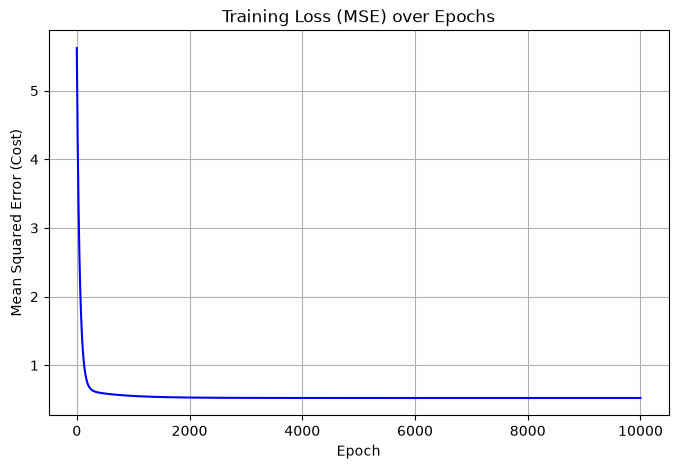

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the training loss curve
plt.figure(figsize=(8, 5))
sns.lineplot(linear_reg.losses, color="b")
plt.title("Training Loss (MSE) over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (Cost)")
plt.grid(True)
plt.show()